# **Практическое задание 1. Обучение полносвязной нейронной сети.**

In [ ]:
# Фоменко Лиза

In [ ]:
import numpy as np
import torch
import cv2
import random

import matplotlib.pyplot as plt

from glob import glob
from collections import OrderedDict
from matplotlib import pyplot as plt

from torch import nn
from torch.autograd import Function
from torch.autograd import gradcheck
from torch.optim import Optimizer, Adam
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision import transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## **1. Загрузка данных (0 баллов)**

Если вам требуется работать с каким-нибудь набором данных (dataset), то, прежде всего, проверьте, нет ли его среди встроенных наборов данных https://pytorch.org/vision/stable/datasets.html.

В текущем домашнем задании мы будем работать с набором данных FashionMNIST. Он присутствует в списке встроенных наборов данных, однако мы воспользуемся реализацией только для удобного и быстрого способа скачать наборы данных. Ниже предлагается реализовать собственный класс для считывания, обработки и упаковки данных.

In [ ]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True
)

# https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html
# root - folder to which dataset will be downloaded
# download - if the dataset is to be downloaded into the root folder (boolean)
# train - pre-split part of dataset (boolean)

100%|██████████| 26.4M/26.4M [00:30<00:00, 860kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 171kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.18MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.3MB/s]


Воспользуемся функцией загрузки данных из репозитория наборов данных.

In [ ]:
! ls data/FashionMNIST/raw

t10k-images-idx3-ubyte	   train-images-idx3-ubyte
t10k-images-idx3-ubyte.gz  train-images-idx3-ubyte.gz
t10k-labels-idx1-ubyte	   train-labels-idx1-ubyte
t10k-labels-idx1-ubyte.gz  train-labels-idx1-ubyte.gz


In [ ]:
#https://github.com/zalandoresearch/fashion-mnist/blob/master/utils/mnist_reader.py
# mnist_reader

def load_mnist(path, kind='train'):
    import os
    import gzip
    import numpy as np

    """Load MNIST data from `path`"""
    labels_path = os.path.join(path,
                               '%s-labels-idx1-ubyte.gz'
                               % kind)
    images_path = os.path.join(path,
                               '%s-images-idx3-ubyte.gz'
                               % kind)

    with gzip.open(labels_path, 'rb') as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8,
                               offset=8)

    with gzip.open(images_path, 'rb') as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8,
                               offset=16).reshape(len(labels), 784)

    return images, labels

Для удобства PyTorch предоставляет ряд базовых классов `Dataset, DataLoader`, от которых предлагается отнаследоваться при разработке пользовательских классов. Базовый класс `Dataset` используется для загрузки и обработки данных, класс `DataLoader` используется для управления процессом загрузки данных, позволяет в многопоточном режиме загружать данные и упаковывать их.
Эти вспомогательные классы находятся в модуле `torch.utils.data`.

При наследовании от класса `torch.utils.data.Dataset` требуется переопределить метод `__len__`, который возвращает количество примеров в наборе данных, а также метод `__getitem__`, который позволяет получить доступ к примеру из набора данных по индексу.

Реализуем класс для FasionMnist.

Элементами датасета должны являться пары '(np.array, int)', массив имеет размерность `(28, 28)`, тип элемента `np.float32`.

In [ ]:
import os

class FashionMnist(Dataset):
    def __init__(self, path, train=True, image_transform=None,
                 label_transform=None):
        if train:
            images, labels = load_mnist(os.path.join(path,"raw"))
        else:
            images, labels = load_mnist(os.path.join(path,"raw"), kind="t10k")

        images = images.reshape(-1,28,28).astype(np.float32)  # reshape pics from (784,) to (28,28)

        if image_transform:  # convert np.arrays into torch.tensors
            images = image_transform(images)
        if label_transform:
            labels = label_transform(labels)
        self.data = images, labels


    def __len__(self,):
        length = self.data[0].shape[0]  # reutrn number of pics in datasets
        return length

    def __getitem__(self, idx):
        img, label = self.data[0][idx], self.data[1][idx]  # pic, label number idx
        return img, label




In [ ]:
test_dataset = FashionMnist("data/FashionMNIST", train=False)
train_dataset = FashionMnist("data/FashionMNIST")

In [ ]:
print(f'train size: {len(train_dataset)};\ntest size: {len(test_dataset)};\nimage size: {train_dataset[0][0].shape};\ndtype: {train_dataset[0][0].dtype}')

train size: 60000;
test size: 10000;
image size: (28, 28);
dtype: float32


Визуализируйте случайные элементы набора данных.

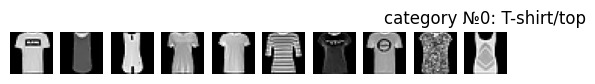

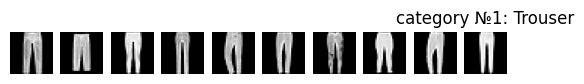

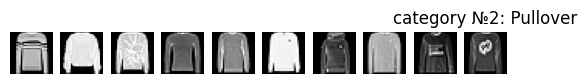

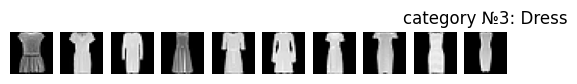

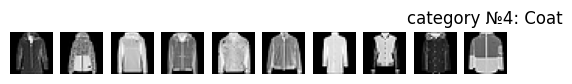

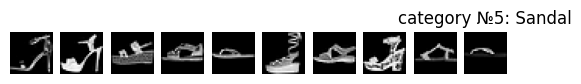

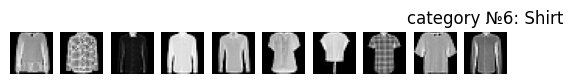

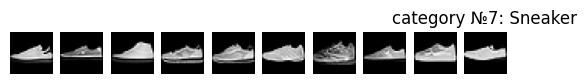

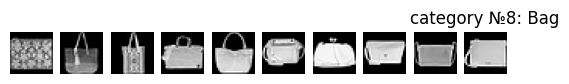

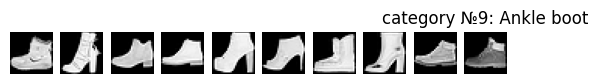

In [ ]:
# draw 10 pics of every category
import matplotlib.pyplot as plt

cat_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
array = train_dataset[list(range(len(train_dataset)))][1]

for cat in range(10):
    fig, axes = plt.subplots(1, 10)
    pics = train_dataset[np.where(array == cat)[:10]][0]
    for _ in range(10):
        axes[_].imshow(pics[_], cmap = 'gray')
        axes[_].axis('off')
    plt.title(f'category №{cat}: {cat_names[cat]}')
    plt.show()

In [ ]:
# проследим за балансом классов

np.unique(train_dataset[list(range(len(train_dataset)))][1], return_counts = True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

В конструктор `Dataset` можно передать объект `torchvision.transforms`, который позволяет преобразовать исходные данные. Преобразование `torchvision.transforms.ToTensor` позволяет преобразоать данные из типа `PIL Image` и `numpy.float32` в тип `torch.float32`

Реализуйте собственную поддержку преобразований в `FashionMnist`. Проверьте, что приведение типов работает корректно.

In [ ]:
class ToTensor:
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample):
        return torch.from_numpy(sample)

In [ ]:
transform = ToTensor()

test_dataset = FashionMnist("data/FashionMNIST",
                            train=False,
                            image_transform=transform,
                            label_transform=transform
                            )

train_dataset = FashionMnist("data/FashionMNIST",
                             image_transform=transform,
                             label_transform=transform
                             )

/tmp/ipython-input-2643605458.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  return torch.from_numpy(sample)


In [ ]:
print(f"The type of the data is {type(test_dataset[0][0])}")

The type of the data is <class 'torch.Tensor'>


In [ ]:
print(f'train size: {len(train_dataset)};\ntest size: {len(test_dataset)};\nimage size: {train_dataset[0][0].shape};\ndtype: {train_dataset[0][0].dtype}')

train size: 60000;
test size: 10000;
image size: torch.Size([28, 28]);
dtype: torch.float32


Элементы набора данных могут быть объединены в пакеты (batch) явно и неявно. Если данные могут быть сконкатенированы или обЪединены каким-нибудь тривиальным способом, то можно не передавать никаких дополнительных парамертов в `torch.utils.data.Dataloader`.

In [ ]:
test_dataloader = DataLoader(test_dataset, batch_size=15, num_workers=2, shuffle=True)
batch = next(iter(test_dataloader))

In [ ]:
print(f"The length of the batch is {len(batch)}")
print(f"The shape of the batch[0] is {batch[0].shape}")

The length of the batch is 2
The shape of the batch[0] is torch.Size([15, 28, 28])


Однако, если наша структура данных не позволяет нам использовать объединение по умолчанию, то можно написать собственную функцию, которая будет пакетировать данные.

Реализуйте функцию, преобразующую последовательность элементов массива в пакет (batch).

In [ ]:
# https://docs.pytorch.org/docs/stable/data.html

def collate(batch):
    imgs, labels = list(zip(*batch))
    imgs, labels = torch.from_numpy(np.array(list(imgs))), torch.from_numpy(np.array(list(labels)))
    return imgs, labels

Убедитесть, что все работает корректно.

In [ ]:
# я добавлю еще val_dataset, который будет составлять 1/2 test_dataset
from sklearn.model_selection import train_test_split

valid_dataset, test_dataset = train_test_split(test_dataset, train_size=0.5)
len(valid_dataset), len(test_dataset)

(5000, 5000)

In [ ]:
test_dataloader = DataLoader(test_dataset, batch_size=15, num_workers=2,
                             shuffle=True, collate_fn=collate)
valid_dataloader = DataLoader(valid_dataset, batch_size=15, num_workers=2,
                             shuffle=True, collate_fn=collate)
train_dataloader = DataLoader(train_dataset, batch_size=15, num_workers=2,
                              shuffle=True, collate_fn=collate)
batch = next(iter(test_dataloader))

In [ ]:
print(f"The length of the batch is {len(batch)}")
print(f"The shape of the batch[0] is {batch[0].shape}")

The length of the batch is 2
The shape of the batch[0] is torch.Size([15, 28, 28])


## **2. Реализация модулей нейронной сети (15 баллов)**

В этом разделе мы полностью реализуем модули для полносвязанной сети.

Для начала нам понадобится реализовать прямой и обратный проход через слои.

Наши слои будут соответствовать следующему интерфейсу (на примере "тождественного" слоя):

Сначала, мы реализуем функцию и её градиент.

In [ ]:
# based on this tutorial https://docs.pytorch.org/tutorials/beginner/examples_autograd/polynomial_custom_function.html
# using this manual https://docs.pytorch.org/docs/stable/generated/torch.autograd.function.FunctionCtx.save_for_backward.html

# explained here https://apxml.com/courses/advanced-pytorch/chapter-1-pytorch-internals-autograd/custom-autograd-functions
# and here https://apxml.com/courses/advanced-pytorch/chapter-1-pytorch-internals-autograd/practice-custom-autograd

# L(x) = x
# dL/d(input) = dL/d(output) * d(output)/d(input) = grad_output * 1

class IdentityFunction(Function):
    """
    We can implement our own custom autograd Functions by subclassing
    torch.autograd.Function and implementing the forward and backward passes
    which operate on Tensors.
    """

    @staticmethod
    def forward(ctx, input):
        """
        In the forward pass we receive a Tensor containing the input and return
        a Tensor containing the output. ctx is a context object that can be used
        to stash information for backward computation. You can cache arbitrary
        objects for use in the backward pass using the ctx.save_for_backward method.
        """
        ctx.save_for_backward(input)
        return input  # L(input) = input

    @staticmethod
    def backward(ctx, grad_output):
        """
        In the backward pass we receive a Tensor containing the gradient of the loss
        with respect to the output, and we need to compute the gradient of the loss
        with respect to the input.
        """
        input = ctx.saved_tensors
        # dL / d_input = (dL / d_output) * (d_output / d_input)
        # dL / d_output = grad_output
        # d_output / d_input = dx / dx = 1
        # dL / d_input = grad_output * 1 = grad_output
        return grad_output

Разработанную функцию обернем классом `IdentityLayer`, все слои в `PyTorch` должны быть наследниками базового класса `nn.Module()`


In [ ]:
class IdentityLayer(nn.Module):
    def __init__(self):
        # An identity layer does nothing
        super().__init__()
        self.identity = IdentityFunction.apply

    def forward(self, inp):
        # An identity layer just returns whatever it gets as input.
        return self.identity(inp)


### **2.1 Функция активации ReLU (1 балл)**
Для начала реализуем функцию активации, слой нелинейности `ReLU(x) = max(x, 0)`. Параметров у слоя нет. Метод `forward` должен вернуть результат поэлементного применения `ReLU` к входному массиву, метод `backward` - градиент функции потерь по входу слоя. В нуле будем считать производную равной 0. Обратите внимание, что при обратном проходе могут понадобиться величины, посчитанные во время прямого прохода, поэтому их стоит сохранить в `ctx`.

In [ ]:
class ReLUFunction(Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return input.clamp(min=0)

    @staticmethod
    def backward(ctx, grad_output):
        input = ctx.saved_tensors[0]
        return (input > 0) * grad_output.clone()  # ReLU'(x) = 1 if x > 0 else 0


class ReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.relu = ReLUFunction.apply


    def forward(self, input):
        return self.relu(input)


Не забываем после реализации функции проверить градиент, испльзуя функцию `gradcheck`.

In [ ]:
torch.manual_seed(57)
relu = ReLU()
n, m = random.randint(1, 10), random.randint(1, 10)
x = torch.randn((n,m), requires_grad=True, dtype=torch.float64)

assert gradcheck(relu, x)

In [ ]:
our_relu = ReLU()
torch_relu = torch.nn.functional.relu

assert torch.norm(torch_relu(x.float()) - our_relu(x)) < 1e-5

### **2.2 Линейный слой (linear, fully-connected) (3 балла)**
Далее реализуем полносвязный слой без нелинейности. У слоя два набора параметра: матрица весов (weights) и вектор смещения (bias).

In [ ]:
class LinearFunction(Function):
    @staticmethod
    def forward(ctx, inp, weight, bias):
        ctx.save_for_backward(inp, weight, bias)
        output = inp @ weight.T + bias
        return output

    @staticmethod
    def backward(ctx, grad_output):
        inp, weight, bias = ctx.saved_tensors
        grad_output = grad_output.clone()
        grad_input = grad_output @ weight  # dL / dx = w
        grad_weight = grad_output.T @ inp  # dL / dw = x
        grad_bias = grad_output.sum(dim = 0)  # dL / db = 1
        return grad_input, grad_weight, grad_bias



class Linear(nn.Module):
    def __init__(self, input_units, output_units):
        super().__init__()
        # initialize weights with small random numbers from normal distribution
        self.weight = torch.nn.Parameter(torch.normal(mean=0.0, std = 0.05, size = (output_units, input_units), requires_grad=True, dtype=torch.float32))
        self.bias = torch.nn.Parameter(torch.normal(mean=0.0, std = 0.05, size = (output_units,), requires_grad=True, dtype=torch.float32))
        self.linearfunc = LinearFunction.apply

    def forward(self,inp):
        return self.linearfunc(inp, self.weight, self.bias)


Проверим градиент, а также сравним с работой нашего модуля с имплементированным в `PyTorch`.

Проверка градиента:

In [ ]:
inpunits = random.randint(5, 20)
outunits = random.randint(5, 20)
torch.manual_seed(57)
linear = Linear(inpunits, outunits)
x = torch.randn((5, inpunits), requires_grad=True, dtype=torch.float32)

assert gradcheck(linear, x, eps = 1e-1)

/usr/local/lib/python3.12/dist-packages/torch/autograd/gradcheck.py:923: UserWarning: Input #0 requires gradient and is not a double precision floating point or complex. This check will likely fail if all the inputs are not of double precision floating point or complex. 
  warnings.warn(


Сравнение с `PyTorch`.

In [ ]:
torch_linear = torch.nn.Linear(inpunits, outunits)
our_linear = Linear(inpunits, outunits)

# generate weight and bias params
weight = torch.randn((outunits, inpunits), requires_grad=True, dtype=torch.float32)
bias = torch.randn((outunits,), requires_grad=True, dtype=torch.float32)

# assign equal params to both models
state_dict = OrderedDict([("weight", weight), ("bias", bias)])
torch_linear.load_state_dict(state_dict)
our_linear.load_state_dict(state_dict)

# compare
assert torch.norm(torch_linear(x.float()) - our_linear(x)) < 1e-5

### **2.3 LogSoftmax (Log + Softmax) (4 балла)**

Для решения задачи многоклассовой классификации обычно используют `softmax` в качестве нелинейности на последнем слое, чтобы получить "оценку" вероятности классов для каждого объекта:$$\hat y = softmax(x)  = \bigl \{\frac {exp(x_i)}{\sum_j exp(x_j)} \bigr \}_{i=1}^K, \quad K - \text{число классов}$$В этом случае удобно оптимизировать логарифм правдоподобия:$$L(y, \hat y) = -\sum_{i=1}^K y_i \log \hat y_i \rightarrow \min,$$где $y_i=1$, если объект принадлежит $i$-му классу, и 0 иначе. Записанная в таком виде, эта функция потерь совпадает с выражением для кросс-энтропии. Очевидно, что ее также можно переписать через индексацию, если через $y_i$ обозначить класс данного объекта:$$L(y, \hat y) = - \log \hat y_{y_i} \rightarrow \min$$В таком виде ее удобно реализовывать.

Реализуйте слой `LogSoftmax` (без параметров). Метод `forward` должен вычислять логарифм от `softmax`, а метод `backward` - пропускать градиенты. В общем случае в промежуточных вычислениях `backward` получится трехмерный тензор, однако для нашей конкретной функции потерь все вычисления можно реализовать в матричном виде. Поэтому мы будем предполагать, что аргумент `grad_output` - это матрица, у которой в каждой строке только одно ненулевое значение (не обязательно единица).

Для полного балла нужна имплементация с `Log-Sum-Exp trick`.

In [ ]:
class LogSoftmaxFunction(Function):
    @staticmethod
    def forward(ctx, inp):
        # log(softmax(x)) = log(exp(x) / sum(exp(x))) = log(exp(x)) - log(sum(exp(x))) = x - log(sum(exp(x))) = x - x_max - log(sum(exp(x-xmax)))

        x_max = inp.max(dim = 1, keepdim=True)[0]  # x_max
        u = torch.log(torch.exp(inp - x_max).sum(dim=1, keepdim = True))  # u = log(sum(exp(x-xmax)))
        logsoftmax = inp - x_max - u
        ctx.save_for_backward(logsoftmax)
        return logsoftmax


    @staticmethod
    def backward(ctx, grad_output):
        logsoftmax = ctx.saved_tensors[0]
        softmax = torch.exp(logsoftmax)
        grad_output = grad_output.clone()
        return grad_output - softmax * grad_output.sum(dim=1, keepdim=True)



class LogSoftmax(nn.Module):
    def __init__(self):
        super().__init__()
        self.logsoftmax = LogSoftmaxFunction.apply

    def forward(self, input):
        return self.logsoftmax(input)

Проверка градиентов.

In [ ]:
x = torch.randn((3,5), requires_grad=True, dtype=torch.float32)
our_logsoftmax = LogSoftmax()

assert gradcheck(our_logsoftmax, x, eps = 1e-2)

In [ ]:
# проверим, что работает правильно
x = torch.randn((3,5), requires_grad=True, dtype=torch.float32)
our_logsoftmax = LogSoftmax()
torch_softmax = nn.LogSoftmax(dim=1)

assert torch.norm(torch_softmax(x.float()) - our_logsoftmax(x)) < 1e-5

### **2.4 Dropout (2 балла)**
Реализуйте слой Dropout.

In [ ]:
class DropoutFunction(Function):
    @staticmethod
    def forward(ctx, inp, p, training):
        if training:
            mask = (torch.rand(inp.shape) > p).float().to(dtype=torch.float32)
            out = inp * mask / (1 - p)
            ctx.save_for_backward(mask / (1 - p))
            return out
        else:
            ctx.save_for_backward(torch.ones(inp.shape))
            return inp


    @staticmethod
    def backward(ctx, grad_output):
        mask, = ctx.saved_tensors
        grad_output = grad_output.clone()
        return grad_output * mask, None, None


class Dropout(nn.Module):
    def __init__(self, p = 0.2):
        super().__init__()
        self.dropout = DropoutFunction.apply
        self.p = p


    def forward(self, input):
        return self.dropout(input, self.p, self.training)

In [ ]:
# had to make a new class where we have no randomness in masking

class DropoutFunction_for_gradcheck(Function):
    @staticmethod
    def forward(ctx, inp, p, training, mask):
        if training:
            mask = (torch.rand(inp.shape) > p).float().to(dtype=torch.float64)
            out = inp * mask / (1 - p)
            out = out
            ctx.save_for_backward(mask / (1 - p))
            return out
        else:
            return inp


    @staticmethod
    def backward(ctx, grad_output):
        mask, = ctx.saved_tensors
        grad_output = grad_output.clone()
        return grad_output * mask, None, None, None


class Dropout_for_gradcheck(nn.Module):
    def __init__(self, p, mask):
        super().__init__()
        self.dropout = DropoutFunction_for_gradcheck.apply
        self.p = p
        self.mask = mask


    def forward(self, input):
        return self.dropout(input, self.p, self.training, self.mask)

In [ ]:
x = torch.randn((3,3), dtype = torch.float64, requires_grad=True)
mask = (torch.rand(x.shape) > 0.2).float().to(dtype=torch.float64)

dropout = Dropout_for_gradcheck(0.2, mask)

assert gradcheck(dropout, x)

### **2.5 CrossEntropy (5 баллов)**

При решении задачи многоклассовой классификации мы будем использовать в качестве функции потерь **кроссэнтропию, совместимую с `LogSoftmax` активацией**.

Реализуйте эту функцию потерь. В разделе 2.3 приведены полезные формулы.

В этом случае удобно оптимизировать логарифм правдоподобия:$$L(y, \hat y) = -\sum_{i=1}^K y_i \log \hat y_i \rightarrow \min,$$где $y_i=1$, если объект принадлежит $i$-му классу, и 0 иначе. Записанная в таком виде, эта функция потерь совпадает с выражением для кросс-энтропии. Очевидно, что ее также можно переписать через индексацию, если через $y_i$ обозначить класс данного объекта:$$L(y, \hat y) = - \log \hat y_{y_i} \rightarrow \min$$В таком виде ее удобно реализовывать.


In [ ]:
class CrossEntropyFunction(Function):
    @staticmethod
    def forward(ctx, log_probs, target):
        target = torch.nn.functional.one_hot(target.long(), num_classes=10)
        loss = - (target * log_probs).sum(dim = 1).mean()
        ctx.save_for_backward(log_probs, target)
        return loss

    @staticmethod
    def backward(ctx, grad_output):
        log_probs, target = ctx.saved_tensors
        return - target / target.size(0)  * grad_output.clone(), None



class CrossEntropy(nn.Module):
    def __init__(self, ):
        super().__init__()
        self.entr = CrossEntropyFunction.apply

    def forward(self, log_probs, target):
        return self.entr(log_probs, target)

Проверка градиентов.

In [ ]:
log_probs = torch.randn((3,10),  dtype=torch.float64, requires_grad=True)
log_probs = torch.log(torch.softmax(log_probs, dim=1))

y = torch.tensor([1,4,3],  dtype=torch.double)
crossentr = CrossEntropy()

assert gradcheck(crossentr, (log_probs, y))

In [ ]:
# проверим, что работает правильно
x = torch.randn((3,10), requires_grad=True, dtype=torch.float32)
log_x = our_logsoftmax(x)
y = torch.tensor([1,4,3],  dtype=torch.double)

our_ce = CrossEntropy()
torch_ce = nn.NLLLoss()

assert torch.norm(torch_ce(log_x.float(), y.long()) - our_ce(log_x, y)) < 1e-5

## **3. Сборка и обучение нейронной сети (5 баллов)**

Реализуйте из ваших блоков персептрон и обучите его, залоггировав итоговый лосс и метрику на валидационной выборке. **(1 балл)**

Подсказка: вытягиваем картинку в вектор с помощью [nn.Flatten](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html)

Ниже приведены функции, реализующие обучение нейронной сети. В данном задании их предлагается просто переиспользовать.

In [ ]:
class EmptyContext:
    def __enter__(self):
        pass

    def __exit__(self, *args):
        pass

In [ ]:
# accuracy metric for our classififcation
def accuracy(model_labels, labels):
    return torch.mean((model_labels == labels).float())

In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    train_losses = []
    for batch, (X, y) in enumerate(dataloader):
        if batch == 0:
            print(y)
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 1000 == 0:
            print(f"loss: {loss.item():>7f}  [{batch * len(X):>5d}/{size:>5d}]")

        if batch % 12 == 0:
            train_losses.append(loss.item())

    return train_losses



def test_loop(dataloader, model, loss_fn):

    model.eval()
    test_losses = []

    size = len(dataloader.dataset)

    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
          pred = model(X)
          test_loss = loss_fn(pred, y).item()
          model_labels = model.predict(X)
          correct += (model_labels == y).type(torch.float).sum().item()

          test_losses.append(test_loss)

    correct /= size
    print(f"Accuracy: {(100*correct):>0.1f}%, Avg loss: {np.array(test_losses).mean():>8f} \n")
    return test_losses


In [ ]:
# make our model

class Network(nn.Module):
    def __init__(self, input_size=28*28, hidden_layers_size=32, num_layers=5,
                 num_classes=10, p = 0.2):
        super().__init__()

        if num_layers == 1:
          layers = [nn.Flatten(), Linear(input_size, num_classes), ReLU(), Dropout(p = 0.2), LogSoftmax()]

        else:
          layers = [nn.Flatten(), Linear(input_size, hidden_layers_size), ReLU(), Dropout(p = 0.2)]

          for _ in range(num_layers - 2):
            layers.append(Linear(hidden_layers_size, hidden_layers_size))
            layers.append(ReLU())
            layers.append(Dropout(p))


          layers.append(Linear(hidden_layers_size, num_classes))
          layers.append(LogSoftmax())

        self.net = nn.Sequential(*layers)


    def forward(self, inp):
        return self.net(inp)

    def predict(self, inp):
        return torch.argmax(self.net(inp), dim = 1)


Теперь обучим нашу нейронную сеть. В данном разделе будем использовать оптимизатор `Adam` с параметрами по умолчанию.

Epoch 0

tensor([4, 2, 7, 9, 9, 4, 0, 7, 0, 2, 5, 3, 4, 4, 4], dtype=torch.uint8)
loss: 2.297391  [    0/60000]
loss: 1.381638  [15000/60000]
loss: 1.013376  [30000/60000]
loss: 0.494163  [45000/60000]
Validation Error:
Accuracy: 73.6%, Avg loss: 0.713540 



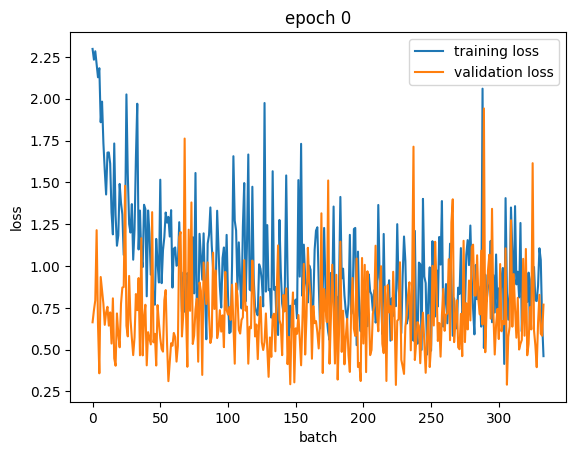

Epoch 1

tensor([5, 0, 5, 8, 2, 3, 3, 8, 3, 3, 0, 1, 6, 2, 8], dtype=torch.uint8)
loss: 0.559478  [    0/60000]
loss: 0.542693  [15000/60000]
loss: 0.838841  [30000/60000]
loss: 0.615618  [45000/60000]
Validation Error:
Accuracy: 73.1%, Avg loss: 0.632963 



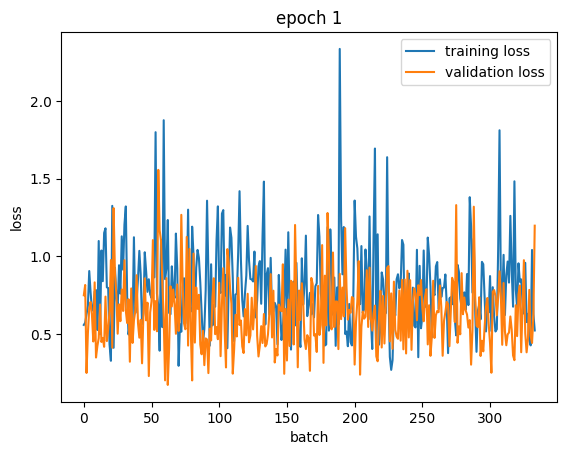

Epoch 2

tensor([1, 3, 0, 3, 9, 7, 2, 7, 2, 1, 9, 4, 8, 2, 3], dtype=torch.uint8)
loss: 0.515894  [    0/60000]
loss: 0.875367  [15000/60000]
loss: 0.734031  [30000/60000]
loss: 1.304189  [45000/60000]
Validation Error:
Accuracy: 73.8%, Avg loss: 0.639351 



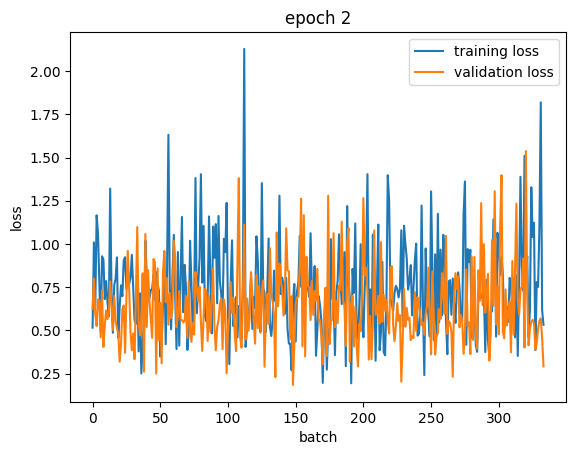

Epoch 3

tensor([3, 7, 8, 9, 0, 2, 3, 5, 3, 7, 5, 7, 1, 6, 6], dtype=torch.uint8)
loss: 0.556765  [    0/60000]
loss: 0.679719  [15000/60000]
loss: 0.345059  [30000/60000]
loss: 0.715106  [45000/60000]
Validation Error:
Accuracy: 77.4%, Avg loss: 0.596936 



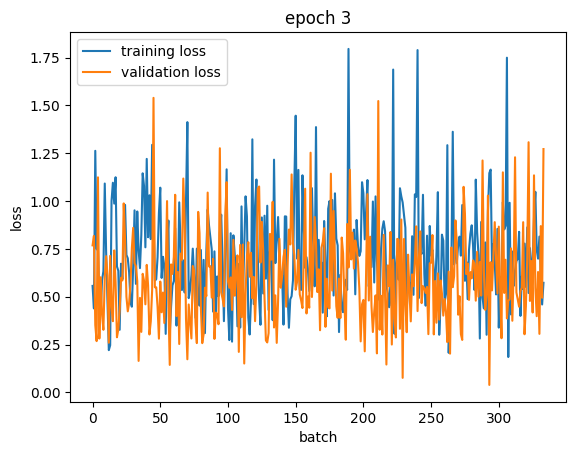

Epoch 4

tensor([9, 2, 5, 4, 1, 5, 3, 0, 7, 4, 0, 3, 8, 4, 3], dtype=torch.uint8)
loss: 0.498065  [    0/60000]
loss: 0.737538  [15000/60000]
loss: 0.763237  [30000/60000]
loss: 0.411275  [45000/60000]
Validation Error:
Accuracy: 76.1%, Avg loss: 0.606240 



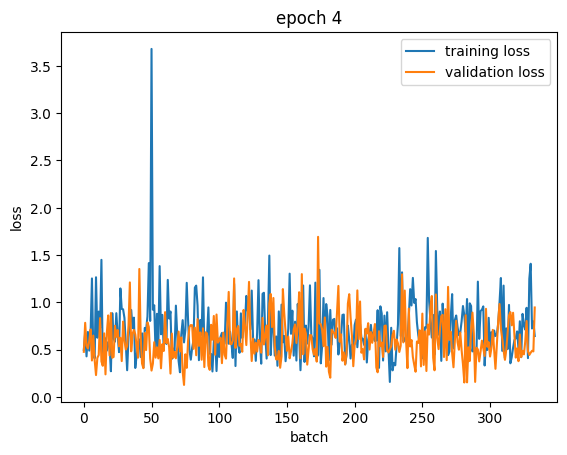

Epoch 5

tensor([3, 9, 1, 2, 0, 4, 7, 4, 2, 2, 3, 6, 0, 9, 9], dtype=torch.uint8)
loss: 0.718539  [    0/60000]
loss: 0.337999  [15000/60000]
loss: 0.626655  [30000/60000]
loss: 0.580103  [45000/60000]
Validation Error:
Accuracy: 77.7%, Avg loss: 0.590722 



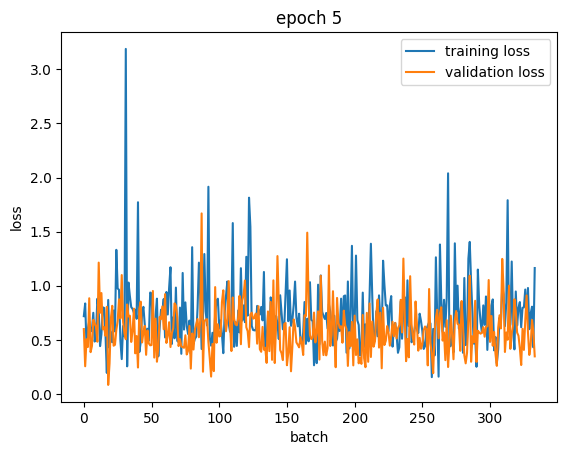

Epoch 6

tensor([9, 3, 5, 2, 3, 5, 2, 6, 0, 2, 2, 7, 5, 8, 2], dtype=torch.uint8)
loss: 0.538583  [    0/60000]
loss: 0.343856  [15000/60000]
loss: 0.507521  [30000/60000]
loss: 0.467919  [45000/60000]
Validation Error:
Accuracy: 73.5%, Avg loss: 0.630948 



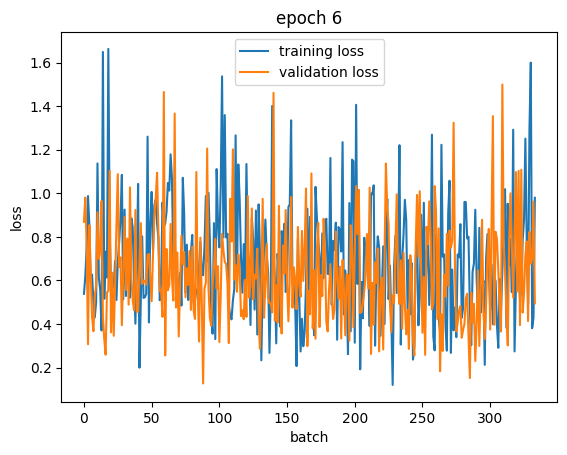

Epoch 7

tensor([8, 1, 0, 6, 1, 5, 7, 1, 9, 3, 0, 9, 5, 6, 7], dtype=torch.uint8)
loss: 0.540896  [    0/60000]
loss: 0.766149  [15000/60000]
loss: 0.558450  [30000/60000]
loss: 0.498494  [45000/60000]
Validation Error:
Accuracy: 78.9%, Avg loss: 0.573590 



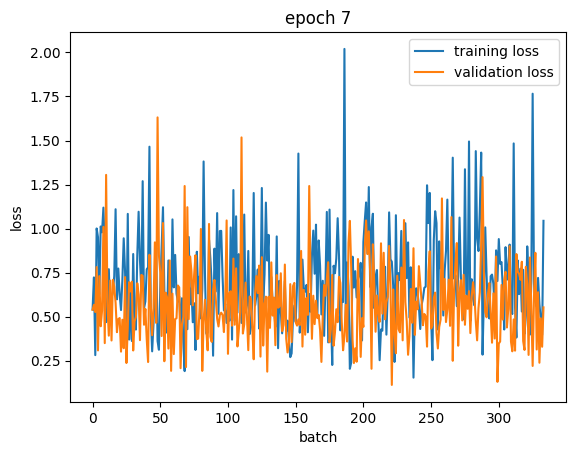

Epoch 8

tensor([7, 0, 6, 6, 0, 4, 2, 6, 5, 2, 3, 1, 0, 3, 2], dtype=torch.uint8)
loss: 0.699938  [    0/60000]
loss: 0.574818  [15000/60000]
loss: 0.680496  [30000/60000]
loss: 0.728012  [45000/60000]
Validation Error:
Accuracy: 76.1%, Avg loss: 0.604198 



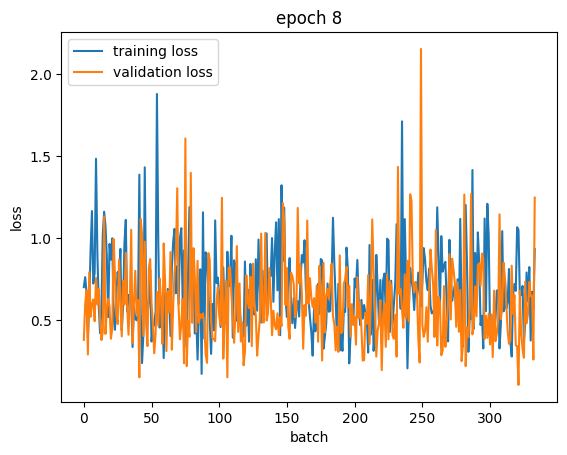

Epoch 9

tensor([1, 3, 2, 2, 1, 0, 2, 9, 4, 2, 9, 2, 4, 5, 5], dtype=torch.uint8)
loss: 0.496632  [    0/60000]
loss: 0.898539  [15000/60000]
loss: 0.497933  [30000/60000]
loss: 0.483552  [45000/60000]
Validation Error:
Accuracy: 78.7%, Avg loss: 0.580387 



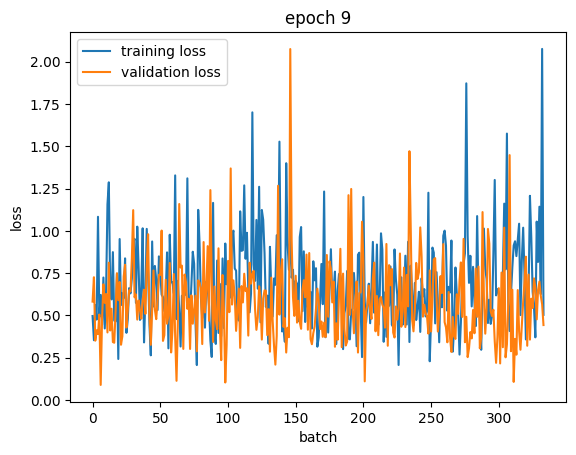

Training: done


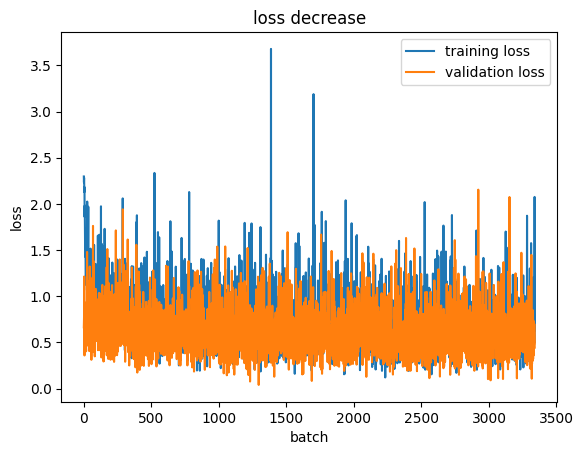

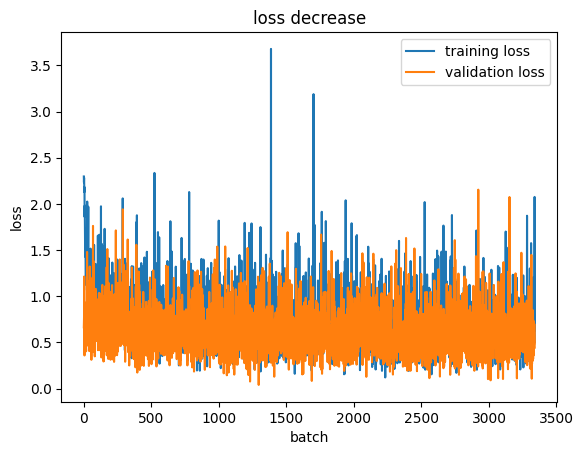


Test Results:
Accuracy: 79.1%, Avg loss: 0.571295 



In [ ]:
epochs = 10

model     = Network(p = 0.25, num_layers=5)
optimizer = torch.optim.Adam(params=model.parameters())
criterion = CrossEntropy()

all_losses_train = []
all_losses_val = []

for t in range(epochs):

    print(f"Epoch {t}\n")

    epoch_train_losses = train_loop(train_dataloader, model, criterion, optimizer)
    all_losses_train = all_losses_train + epoch_train_losses

    print('Validation Error:')


    epoch_val_losses = test_loop(valid_dataloader, model, criterion)
    all_losses_val = all_losses_val + epoch_val_losses

    plt.plot(range(len(epoch_train_losses)), epoch_train_losses, label = 'training loss')
    plt.plot(range(len(epoch_val_losses)), epoch_val_losses, label = 'validation loss')
    plt.xlabel('batch')
    plt.ylabel('loss')
    plt.title(f'epoch {t}')
    plt.legend()
    plt.show()


print("Training: done")


plt.plot(range(len(all_losses_train)), all_losses_train, label = 'training loss')
plt.plot(range(len(all_losses_val)), all_losses_val, label = 'validation loss')
plt.xlabel('batch')
plt.ylabel('loss')
plt.title(f'loss decrease')
plt.legend()
plt.show()

print('\nTest Results:')
a = test_loop(test_dataloader, model, criterion)




In [ ]:
# Test Results:
# Accuracy: 79.1%, Avg loss: 0.571295

Дальше **(4 балла)**:
- Проведите эксперименты с числом слоев.
- Постройте графики зависимости качества модели на тренировочной и тестовой выборках от числа слоев. Для получения статистически значимых результатов повторите эксперименты несколько раз.
- Сделайте выводы.

Training Loop для выполнения этой части задания можно и нужно улучшать, в том числе, добавляя более продвинутое логгирование эксперимента.

num_layers = 1 done
num_layers = 2 done
num_layers = 3 done
num_layers = 4 done
num_layers = 5 done
num_layers = 6 done
num_layers = 7 done


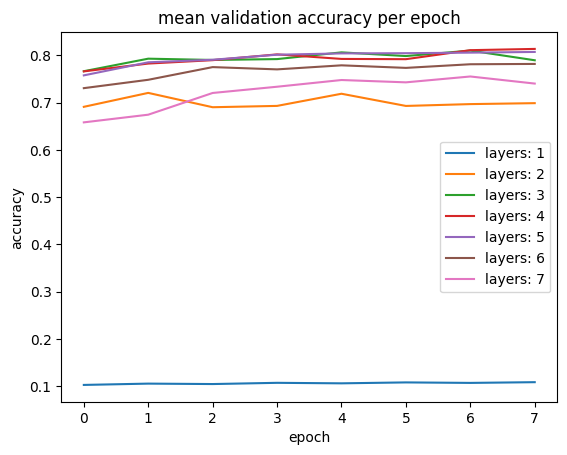

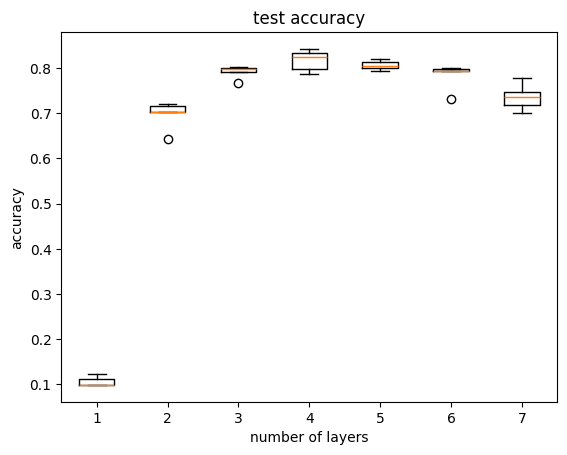

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def train_loop(dataloader, model, loss_fn, optimizer, losses):
    size = len(dataloader.dataset)
    model.train()
    train_losses = []
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        losses.append(loss.item())

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return losses


def test_loop(dataloader, model, loss_fn):

    model.eval()
    test_losses = []

    size = len(dataloader.dataset)

    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
          pred = model(X)
          test_loss = loss_fn(pred, y).item()
          model_labels = model.predict(X)
          correct += (model_labels == y).type(torch.float).sum().item()

          test_losses.append(test_loss)

    correct /= size
    return correct




def run_model_cycle(epochs):

    train_losses = []
    val_acc = []


    for t in range(epochs):
        acc_epochs = []

        train_losses = train_loop(train_dataloader, model, criterion, optimizer, train_losses)

        val_acc.append(test_loop(valid_dataloader, model, criterion))

    test_acc = test_loop(test_dataloader, model, criterion)

    return train_losses, val_acc, test_acc


num_layers_arr = range(1, 8)  # number of layers
num_repeats = 5  # get stat significant results
epochs = 8  # number of epochs


test_accs = []


for num_layers in num_layers_arr:

    layer_train_losses = []
    layer_val_acc = []
    layer_test_acc = []


    for rep in range(num_repeats):

        model     = Network(p = 0.25, num_layers=num_layers)
        optimizer = torch.optim.Adam(params=model.parameters())
        criterion = CrossEntropy()

        train_losses, val_acc, test_acc = run_model_cycle(epochs)

        layer_train_losses.append(train_losses)
        layer_val_acc.append(val_acc)
        layer_test_acc.append(test_acc)


    val_acc_per_epoch = list(zip(*layer_val_acc))
    val_acc_per_epoch = np.array(val_acc_per_epoch).mean(axis = 1)
    test_accs.append(layer_test_acc)

    plt.plot(range(epochs), val_acc_per_epoch, label = f'layers: {num_layers}')
    print(f'num_layers = {num_layers} done')

plt.title('mean validation accuracy per epoch')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()


plt.boxplot(test_accs)
plt.xticks(range(1, len(num_layers_arr)+1), num_layers_arr)
plt.title('test accuracy')
plt.xlabel('number of layers')
plt.ylabel('accuracy')
plt.show()


In [ ]:
np.array(test_accs).mean(axis = 1)

array([0.10628, 0.69748, 0.79164, 0.81648, 0.806  , 0.78316, 0.73592])

In [ ]:
# наверное не стоило использовать "сеть" с 1 слоем, так как из-за нее довольно плохо различимы остальные графики :) но с ней даже нагляднее!
# мы видим, что модели с 3-6 слоями выдают наилучший результат, оптимальное количество слоев для такой модели 4-5.

# сеть с 1-2 слоями работают плохо потому, что им не хватает парамтров для выучивания необходимых паттернов
# сеть с 7+ слоями. Скорее всего, сеть просто переобучивается (accuracy на train вывести забыла)

# очевидно, что на F-MNIST можно добиться куда лучшего качества. Для этого можно попробовать поменять вероятности дропаута нейронов,
# подобрать значение learning_rate для Adam (например, OneCycleLR) и тд. Также можно было бы внести BatchNorm и кучу чего еще :)

## **4. Бонусная часть.**

### **4.1 Реализация метода оптимизации (3 + 3 балла).**
Реализуйте сами метод оптимизации  для рассмотренной выше архитектуры. Вы можете выбрать произвольный метод от градиентного спуска до современных вариантов. Продемонстрируйте правильную работу метода оптимизации, сравните его работы с Adam.

**Дополнительные баллы** вы получите, если метод будет уникален среди сдавших задание.

In [ ]:
# мы использовали Adam. А я попробую реализовать Adan (Adaptive Nesterov Momentum Algorithm)
# авторы подчеркивают, что немногие современные оптимизаторы используют момент нестерова, хотя он "в теории приводит к более быстрой сходимости"
# ссылка на статью - https://doi.org/10.48550/arXiv.2208.06677

# из нее нужно реализовать алгоритм №1

# инициализация параметров -- we set m0 = g0, v0 = 0, v1 =g1-g0, and n0 = g0^2.
#We set β1 = 0.02, β2 = 0.08 and β3 = 0.01, and let weight decay be 0.02 unless noted otherwise
class SotaOptimizerAdan(Optimizer):
    def __init__(self, params, lr=1e-3, betas = [0.02, 0.08, 0.01], eps = 1e-10, weight_decay = 0.02):
        defaults = dict(lr=lr,
                        betas = betas,
                        eps = eps,
                        weight_decay = weight_decay)
        super(SotaOptimizerAdan, self).__init__(params, defaults)

    def __setstate__(self, state):
        super(SotaOptimizerAdan, self).__setstate__(state)

    @torch.no_grad()
    def step(self,):

        for group in self.param_groups:
            lr = group['lr']
            beta1, beta2, beta3 = group['betas']
            eps = group['eps']
            weight_decay = group['weight_decay']

            for p in group['params']:
                if p.grad is not None:

                    # get parameters data and stored gradients
                    data, grad = p.data, p.grad

                    # states of optimizer for our parameter
                    state = self.state[p]

                    # if no state is stored, we need to initialize them
                    if len(state) == 0:
                        state['step'] = 0
                        state['prev_grad'] = torch.zeros_like(grad)
                        state['m'] = grad.clone()
                        state['v'] = torch.zeros_like(grad)
                        state['n'] = grad.clone()**2

                    # get everything we need for the parameter
                    step, prev_grad, m, v, n = state.values()

                    step += 1                                                            # increase step
                    m = (1. - beta1) * m + beta1 * grad                                  # m_k
                    grad_diff = grad - prev_grad                                         # we need it in several formulas
                    v = (1. - beta2) * v + beta2 * grad_diff                             # v_k
                    n = (1. - beta3) * n + beta3 * (grad - (1. - beta2)*grad_diff)**2    # n_k
                    step_weight = lr / (n**0.5 + eps)                                    # theta_k

                    # update params
                    data = (data - step_weight * (m + (1. - beta2)*v)) / (1. + lr*weight_decay)
                    p.data = data

                    # set new params! and we are done
                    state['step'] = step
                    state['prev_grad'] = grad.clone()
                    state['m'] = m
                    state['v'] = v
                    state['n'] = n

Epoch 0

tensor([8, 8, 0, 3, 3, 0, 3, 3, 2, 1, 5, 6, 7, 1, 2], dtype=torch.uint8)
loss: 2.352441  [    0/60000]
loss: 0.849007  [15000/60000]
loss: 0.992988  [30000/60000]
loss: 0.845994  [45000/60000]
Validation Error:
Accuracy: 77.0%, Avg loss: 0.683720 



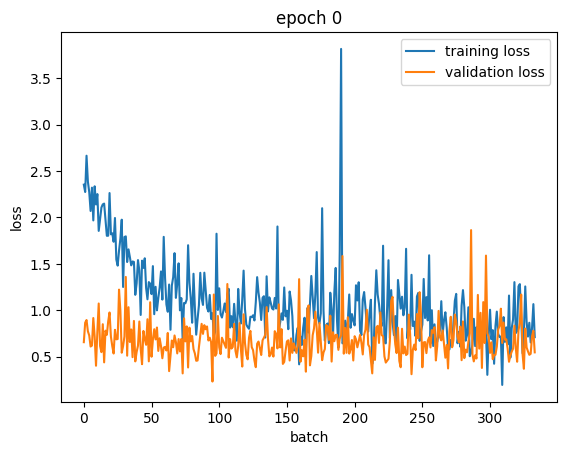

Epoch 1

tensor([0, 6, 1, 5, 8, 2, 0, 3, 0, 5, 3, 0, 9, 0, 9], dtype=torch.uint8)
loss: 0.592467  [    0/60000]
loss: 0.592346  [15000/60000]
loss: 0.509928  [30000/60000]
loss: 0.270240  [45000/60000]
Validation Error:
Accuracy: 78.9%, Avg loss: 0.652583 



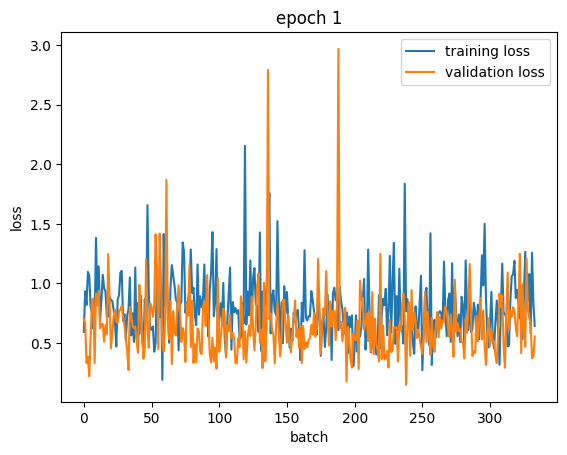

Epoch 2

tensor([2, 9, 6, 9, 7, 0, 8, 3, 4, 7, 9, 3, 9, 1, 6], dtype=torch.uint8)
loss: 0.779333  [    0/60000]
loss: 0.986024  [15000/60000]
loss: 0.434983  [30000/60000]
loss: 0.576678  [45000/60000]
Validation Error:
Accuracy: 79.6%, Avg loss: 0.586944 



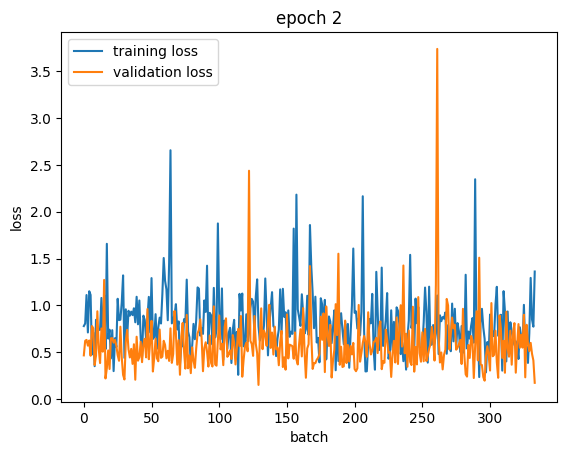

Epoch 3

tensor([9, 4, 4, 9, 2, 8, 3, 0, 4, 2, 4, 5, 5, 8, 9], dtype=torch.uint8)
loss: 0.665938  [    0/60000]
loss: 1.397881  [15000/60000]
loss: 0.816703  [30000/60000]
loss: 0.228407  [45000/60000]
Validation Error:
Accuracy: 79.5%, Avg loss: 0.607484 



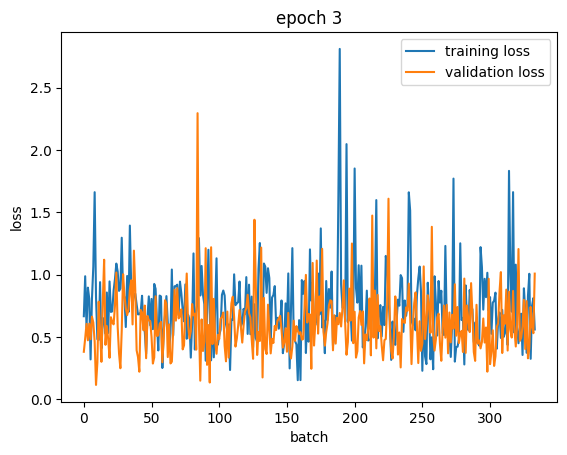

Epoch 4

tensor([7, 2, 9, 5, 2, 1, 3, 4, 5, 8, 2, 9, 3, 0, 2], dtype=torch.uint8)
loss: 0.598713  [    0/60000]
loss: 0.587679  [15000/60000]
loss: 0.361006  [30000/60000]
loss: 0.509488  [45000/60000]
Validation Error:
Accuracy: 80.7%, Avg loss: 0.581270 



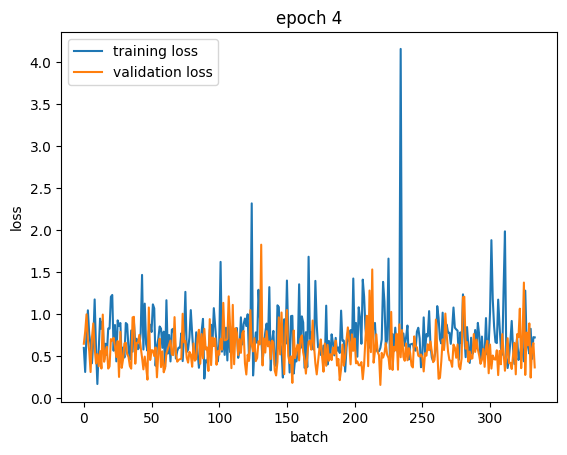

Epoch 5

tensor([6, 1, 0, 2, 5, 7, 8, 1, 7, 8, 0, 1, 2, 5, 0], dtype=torch.uint8)
loss: 0.536060  [    0/60000]
loss: 0.725435  [15000/60000]
loss: 0.586271  [30000/60000]
loss: 0.931304  [45000/60000]
Validation Error:
Accuracy: 81.0%, Avg loss: 0.586097 



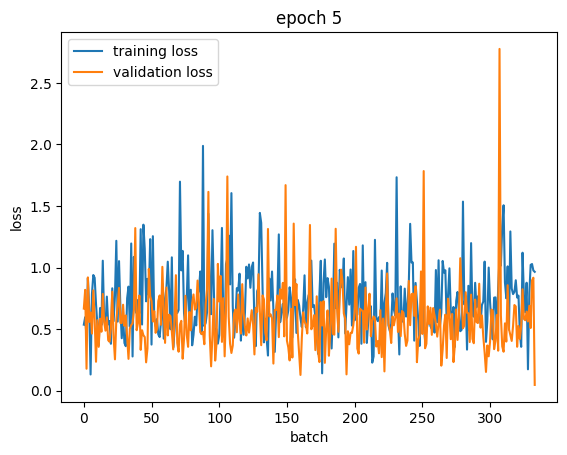

Epoch 6

tensor([9, 0, 8, 9, 2, 9, 8, 0, 7, 3, 3, 4, 4, 1, 7], dtype=torch.uint8)
loss: 0.442515  [    0/60000]
loss: 0.836847  [15000/60000]
loss: 0.903351  [30000/60000]
loss: 0.543051  [45000/60000]
Validation Error:
Accuracy: 81.0%, Avg loss: 0.576489 



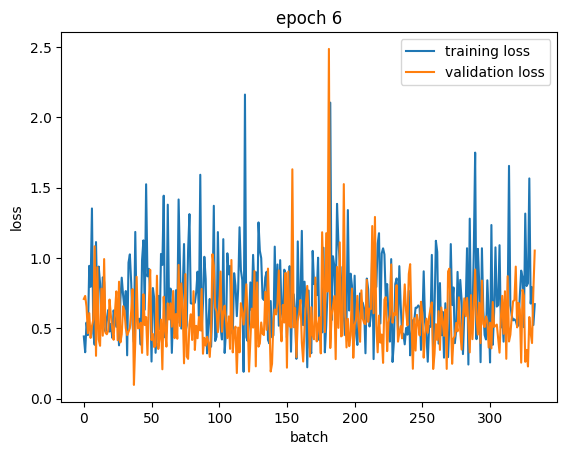

Epoch 7

tensor([5, 1, 6, 6, 4, 3, 0, 7, 6, 5, 6, 5, 7, 0, 0], dtype=torch.uint8)
loss: 0.562120  [    0/60000]
loss: 0.560684  [15000/60000]
loss: 0.641458  [30000/60000]
loss: 0.593609  [45000/60000]
Validation Error:
Accuracy: 79.8%, Avg loss: 0.609053 



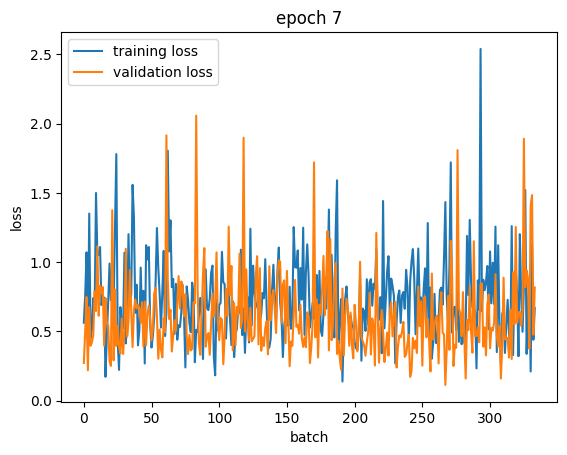

Epoch 8

tensor([8, 7, 6, 7, 9, 7, 3, 2, 0, 1, 4, 2, 2, 0, 2], dtype=torch.uint8)
loss: 0.371234  [    0/60000]
loss: 0.645812  [15000/60000]
loss: 0.687437  [30000/60000]
loss: 0.956000  [45000/60000]
Validation Error:
Accuracy: 77.6%, Avg loss: 0.635823 



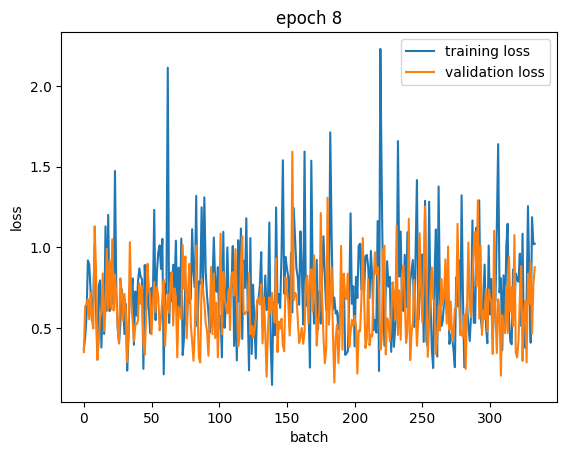

Epoch 9

tensor([1, 4, 0, 9, 0, 6, 3, 7, 2, 5, 0, 8, 3, 0, 3], dtype=torch.uint8)
loss: 1.208211  [    0/60000]
loss: 0.677420  [15000/60000]
loss: 0.866285  [30000/60000]
loss: 1.001266  [45000/60000]
Validation Error:
Accuracy: 80.4%, Avg loss: 0.582924 



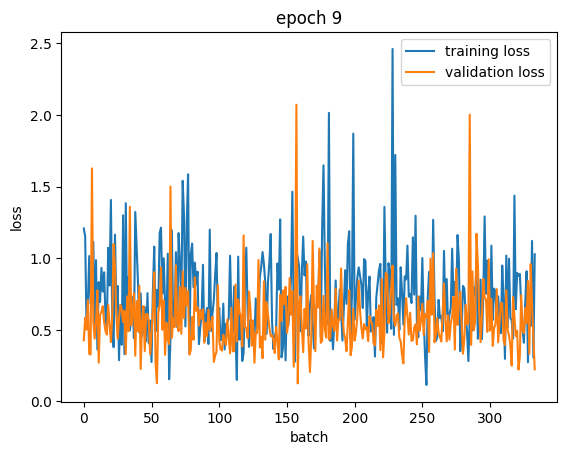

Training: done


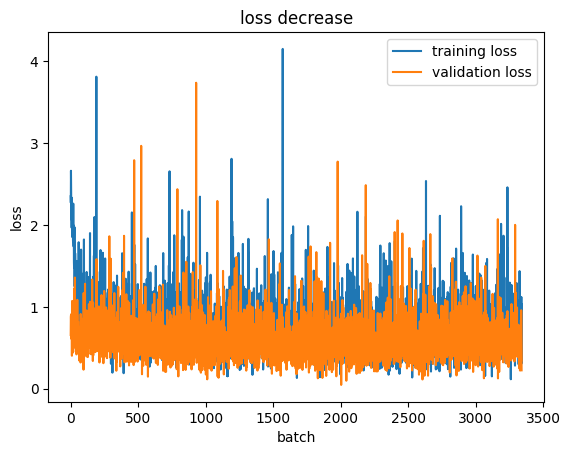


Test Results:
Accuracy: 79.5%, Avg loss: 0.615155 



In [ ]:
epochs = 10

model     = Network(p = 0.25, num_layers=5)
optimizer = SotaOptimizerAdan(params=model.parameters())
criterion = CrossEntropy()

all_losses_train = []
all_losses_val = []

for t in range(epochs):

    print(f"Epoch {t}\n")

    epoch_train_losses = train_loop(train_dataloader, model, criterion, optimizer)
    all_losses_train = all_losses_train + epoch_train_losses

    print('Validation Error:')


    epoch_val_losses = test_loop(valid_dataloader, model, criterion)
    all_losses_val = all_losses_val + epoch_val_losses

    plt.plot(range(len(epoch_train_losses)), epoch_train_losses, label = 'training loss')
    plt.plot(range(len(epoch_val_losses)), epoch_val_losses, label = 'validation loss')
    plt.xlabel('batch')
    plt.ylabel('loss')
    plt.title(f'epoch {t}')
    plt.legend()
    plt.show()


print("Training: done")


plt.plot(range(len(all_losses_train)), all_losses_train, label = 'training loss')
plt.plot(range(len(all_losses_val)), all_losses_val, label = 'validation loss')
plt.xlabel('batch')
plt.ylabel('loss')
plt.title(f'loss decrease')
plt.legend()
plt.show()

print('\nTest Results:')
a = test_loop(test_dataloader, model, criterion)




In [ ]:
# Test Results:
# Accuracy: 79.5%, Avg loss: 0.615155

# проведу тест по количеству слеов, но возьму только оптимальные значения (3-6). число повторов поставлю на 3, а эпох - на 5 (в качестве экономии)

num_layers = 3 done
num_layers = 4 done
num_layers = 5 done
num_layers = 6 done


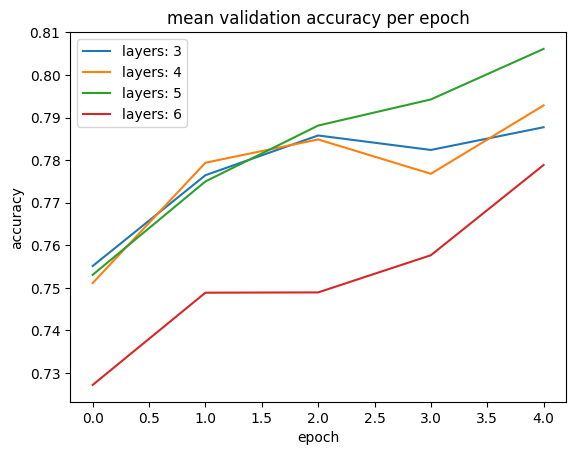

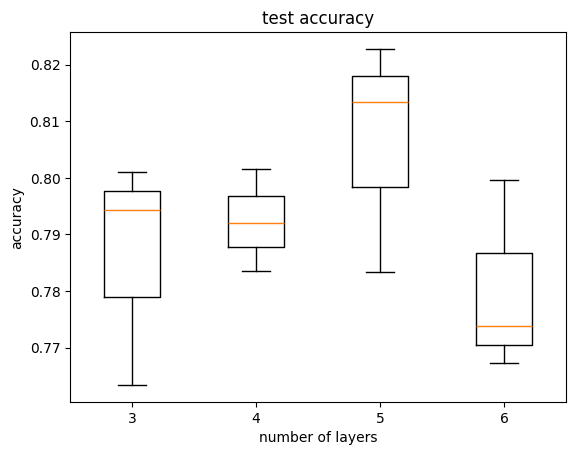

In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer, losses):
    size = len(dataloader.dataset)
    model.train()
    train_losses = []
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        losses.append(loss.item())

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return losses


def test_loop(dataloader, model, loss_fn):

    model.eval()
    test_losses = []

    size = len(dataloader.dataset)

    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
          pred = model(X)
          test_loss = loss_fn(pred, y).item()
          model_labels = model.predict(X)
          correct += (model_labels == y).type(torch.float).sum().item()

          test_losses.append(test_loss)

    correct /= size
    return correct




def run_model_cycle(epochs):

    train_losses = []
    val_acc = []


    for t in range(epochs):
        acc_epochs = []

        train_losses = train_loop(train_dataloader, model, criterion, optimizer, train_losses)

        val_acc.append(test_loop(valid_dataloader, model, criterion))

    test_acc = test_loop(test_dataloader, model, criterion)

    return train_losses, val_acc, test_acc


num_layers_arr = range(3, 7)  # number of layers
num_repeats = 3  # get stat significant results
epochs = 5  # number of epochs


test_accs = []


for num_layers in num_layers_arr:

    layer_train_losses = []
    layer_val_acc = []
    layer_test_acc = []


    for rep in range(num_repeats):

        model     = Network(p = 0.25, num_layers=num_layers)
        optimizer = SotaOptimizerAdan(params=model.parameters())
        criterion = CrossEntropy()

        train_losses, val_acc, test_acc = run_model_cycle(epochs)

        layer_train_losses.append(train_losses)
        layer_val_acc.append(val_acc)
        layer_test_acc.append(test_acc)


    val_acc_per_epoch = list(zip(*layer_val_acc))
    val_acc_per_epoch = np.array(val_acc_per_epoch).mean(axis = 1)
    test_accs.append(layer_test_acc)

    plt.plot(range(epochs), val_acc_per_epoch, label = f'layers: {num_layers}')
    print(f'num_layers = {num_layers} done')

plt.title('mean validation accuracy per epoch')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()


plt.boxplot(test_accs)
plt.xticks(range(1, len(num_layers_arr)+1), num_layers_arr)
plt.title('test accuracy')
plt.xlabel('number of layers')
plt.ylabel('accuracy')
plt.show()


In [ ]:
np.array(test_accs).mean(axis = 1)

array([0.78626667, 0.7924    , 0.80653333, 0.7802    ])

In [ ]:
# напомню, что Adam справился вот так:
# 0.79164, 0.81648, 0.806  , 0.78316

# оптимизаторы дали очень похожий результат. практически идентичный :)

### **4.2 Реализация современной функции активации (2 + 2 балла).**
Реализуйте одну из активаций, предложенных на лекции или в статье. Например, `Hardswish`. Сравните сеть с вашей активацией и с `ReLU`.

**Дополнительные баллы** вы получите, если функция будет уникальна среди сдавших задание.

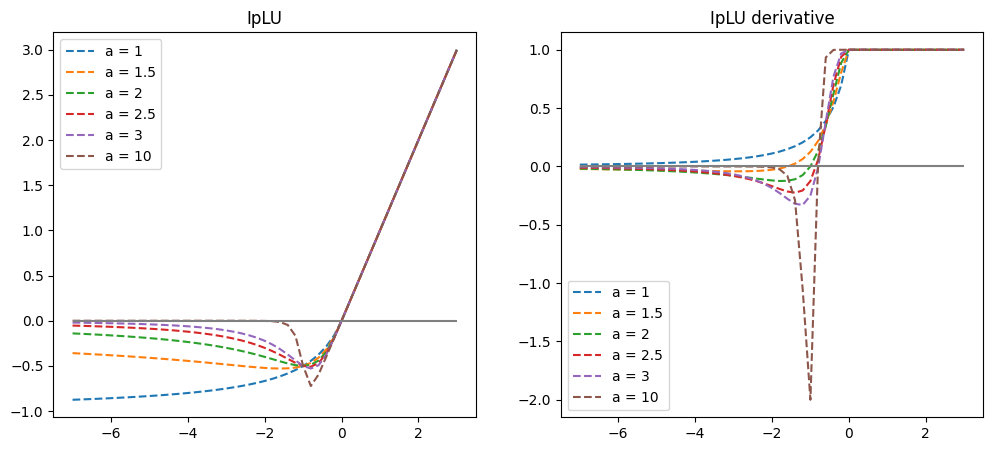

In [ ]:
# буду использовать IpLU = Inverse polynomial linear units
# Wu et al., 2021, https://ieeexplore.ieee.org/document/9446115

# IpLU = x if x >= 0 else x / (1 + |x|^a)
# grad = 1 if x >= 0 else (1 + |x|^a - x^2*a*|x|^(a-2)) / (1+|x|^a)^2

# нарисуем ее

def calc_IpLU(a, x):
    powered_input = 1 + torch.abs(x)**a
    out = x / powered_input
    idx = np.where(x >= 0)
    out[idx] = x[idx]

    grad = (powered_input - x**2 * a * torch.abs(x)**(a-2)) / (powered_input)**2
    idx = np.where(x >= 0)
    grad[idx] = 1

    return out, grad



x = torch.linspace(-7, 3, steps=51)
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for a in [1, 1.5, 2, 2.5, 3, 10]:
    out, grad = calc_IpLU(a, x)
    ax1.plot(x, out, label = f'a = {a}', linestyle='dashed')
    ax2.plot(x, grad, label = f'a = {a}', linestyle='dashed')

ax1.set_title('IpLU')
ax2.set_title('IpLU derivative')
ax1.legend()
ax1.hlines(y=0, xmin = -7, xmax = 3, color = 'gray')
ax2.legend()
ax2.hlines(y=0, xmin = -7, xmax = 3, color = 'gray')
plt.show()


In [ ]:
# нужно выбрать параметр a. я выберу почти наугад по графику: пусть а = 2.5

class IpLUFunction(Function):
    @staticmethod
    def forward(ctx, input, a = 2.5):
        powered_input = 1 + torch.abs(input)**a
        ctx.save_for_backward(input, powered_input)
        ctx.a = a
        out = input / powered_input
        idx = np.where(input >= 0)
        out[idx] = input[idx]
        return out

    @staticmethod
    def backward(ctx, grad_output):
        input, powered_input = ctx.saved_tensors
        a = ctx.a
        grad = (powered_input - input**2 * a * torch.abs(input)**(a-2)) / (powered_input)**2
        idx = np.where(input >= 0)
        grad[idx] = 1
        return grad * grad_output.clone(), None


class IpLU(nn.Module):
    def __init__(self, alpha = 2.5):
        super().__init__()
        self.a = alpha
        self.iplu = IpLUFunction.apply


    def forward(self, input):
        return self.iplu(input, self.a)




torch.manual_seed(57)
relu = IpLU(2)
n, m = random.randint(1, 10), random.randint(1, 10)
x = torch.randn((n,m), requires_grad=True, dtype=torch.float64)

assert gradcheck(relu, x)

In [ ]:
class IpLUNetwork(nn.Module):
    def __init__(self, input_size=28*28, hidden_layers_size=32, num_layers=5,
                 num_classes=10, p = 0.2, iplu_a = 2):
        super().__init__()

        if num_layers == 1:
          layers = [nn.Flatten(), Linear(input_size, num_classes), IpLU(iplu_a), Dropout(p = 0.2), LogSoftmax()]

        else:
          layers = [nn.Flatten(), Linear(input_size, hidden_layers_size), IpLU(iplu_a), Dropout(p = 0.2)]

          for _ in range(num_layers - 2):
            layers.append(Linear(hidden_layers_size, hidden_layers_size))
            layers.append(IpLU(iplu_a))
            layers.append(Dropout(p))


          layers.append(Linear(hidden_layers_size, num_classes))
          layers.append(LogSoftmax())

        self.net = nn.Sequential(*layers)


    def forward(self, inp):
        return self.net(inp)

    def predict(self, inp):
        return torch.argmax(self.net(inp), dim = 1)


Epoch 0

tensor([0, 3, 7, 7, 5, 7, 4, 8, 5, 8, 8, 2, 4, 0, 3], dtype=torch.uint8)
loss: 2.327962  [    0/60000]
loss: 1.167773  [15000/60000]
loss: 0.693643  [30000/60000]
loss: 0.747115  [45000/60000]
Validation Error:
Accuracy: 68.8%, Avg loss: 0.780310 



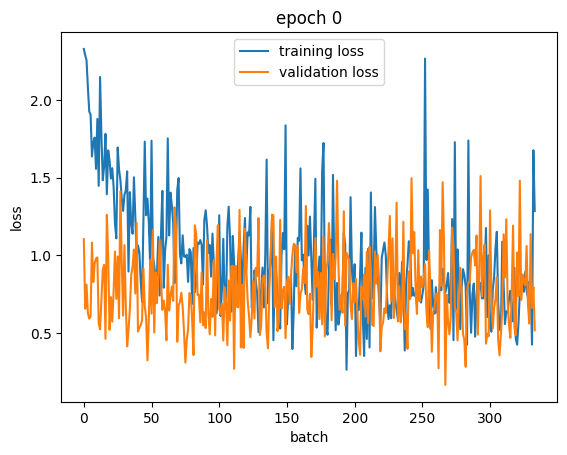

Epoch 1

tensor([7, 1, 4, 9, 3, 7, 4, 1, 8, 0, 5, 5, 4, 9, 9], dtype=torch.uint8)
loss: 1.259310  [    0/60000]
loss: 0.443461  [15000/60000]
loss: 0.812973  [30000/60000]
loss: 0.603740  [45000/60000]
Validation Error:
Accuracy: 74.0%, Avg loss: 0.643306 



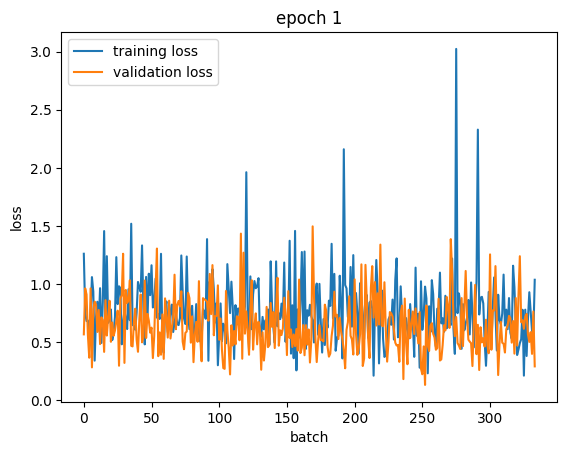

Epoch 2

tensor([1, 3, 1, 3, 0, 5, 0, 1, 7, 3, 2, 5, 1, 0, 6], dtype=torch.uint8)
loss: 1.011307  [    0/60000]
loss: 0.704506  [15000/60000]
loss: 0.714399  [30000/60000]
loss: 1.093115  [45000/60000]
Validation Error:
Accuracy: 74.1%, Avg loss: 0.615665 



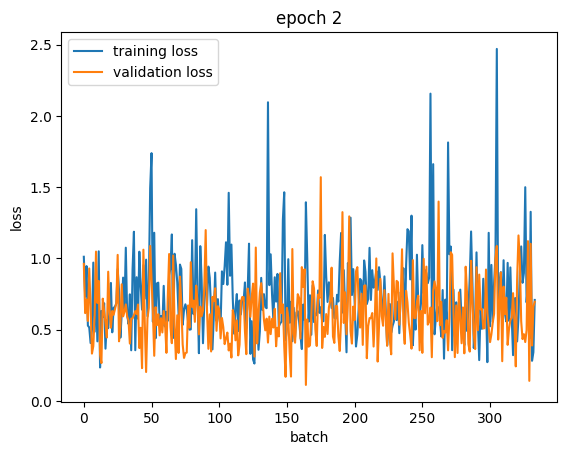

Epoch 3

tensor([4, 9, 9, 7, 7, 6, 2, 2, 2, 7, 8, 7, 7, 2, 4], dtype=torch.uint8)
loss: 0.617767  [    0/60000]
loss: 0.516168  [15000/60000]
loss: 0.789290  [30000/60000]
loss: 0.604428  [45000/60000]
Validation Error:
Accuracy: 75.1%, Avg loss: 0.597325 



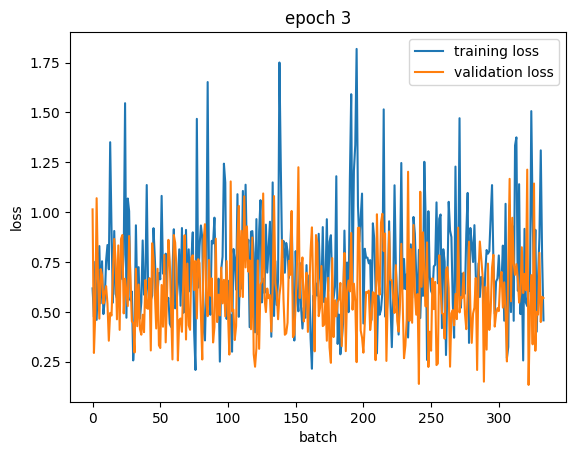

Epoch 4

tensor([7, 3, 9, 9, 2, 3, 9, 8, 1, 6, 5, 9, 1, 4, 1], dtype=torch.uint8)
loss: 0.419860  [    0/60000]
loss: 0.993239  [15000/60000]
loss: 1.517246  [30000/60000]
loss: 0.676774  [45000/60000]
Validation Error:
Accuracy: 76.4%, Avg loss: 0.607829 



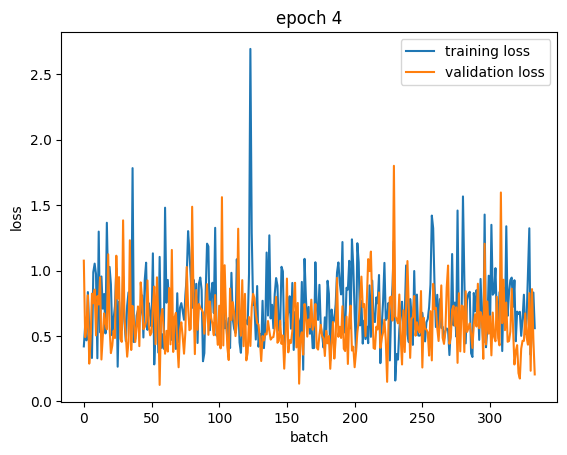

Epoch 5

tensor([4, 2, 9, 9, 3, 6, 0, 0, 9, 6, 3, 7, 3, 5, 6], dtype=torch.uint8)
loss: 0.778778  [    0/60000]
loss: 0.572764  [15000/60000]
loss: 0.706096  [30000/60000]
loss: 0.712511  [45000/60000]
Validation Error:
Accuracy: 74.4%, Avg loss: 0.636529 



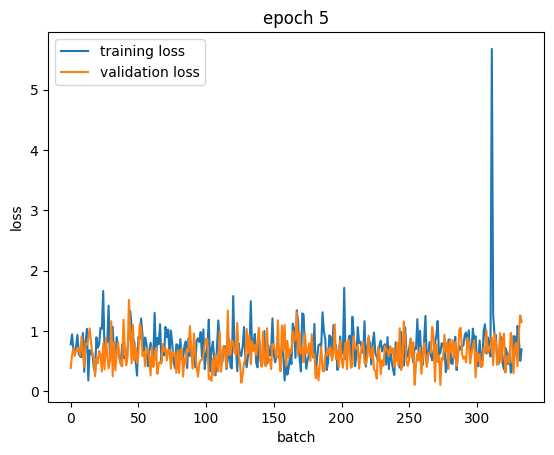

Epoch 6

tensor([9, 1, 1, 3, 9, 0, 8, 4, 1, 0, 1, 7, 0, 4, 0], dtype=torch.uint8)
loss: 0.956959  [    0/60000]
loss: 1.062274  [15000/60000]
loss: 0.927844  [30000/60000]
loss: 1.010844  [45000/60000]
Validation Error:
Accuracy: 75.1%, Avg loss: 0.639443 



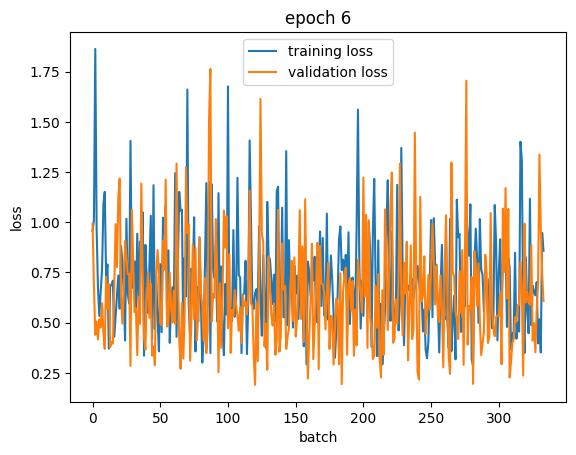

Epoch 7

tensor([2, 3, 9, 6, 0, 9, 4, 9, 3, 2, 8, 9, 6, 2, 2], dtype=torch.uint8)
loss: 0.592282  [    0/60000]
loss: 0.455804  [15000/60000]
loss: 0.227157  [30000/60000]
loss: 0.690067  [45000/60000]
Validation Error:
Accuracy: 75.5%, Avg loss: 0.609180 



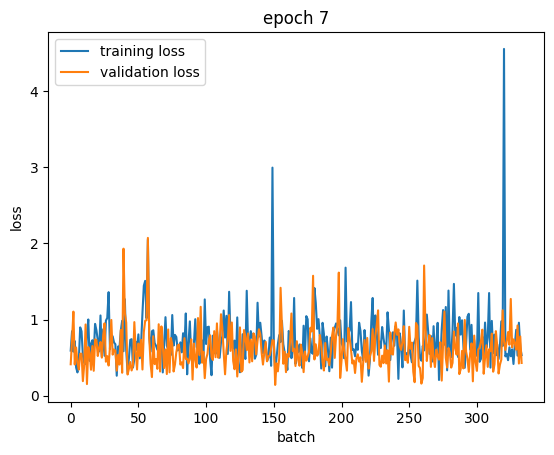

Epoch 8

tensor([6, 9, 0, 6, 3, 0, 2, 9, 5, 1, 8, 8, 4, 8, 8], dtype=torch.uint8)
loss: 0.457015  [    0/60000]
loss: 0.812036  [15000/60000]
loss: 0.970047  [30000/60000]
loss: 0.781433  [45000/60000]
Validation Error:
Accuracy: 74.3%, Avg loss: 0.685121 



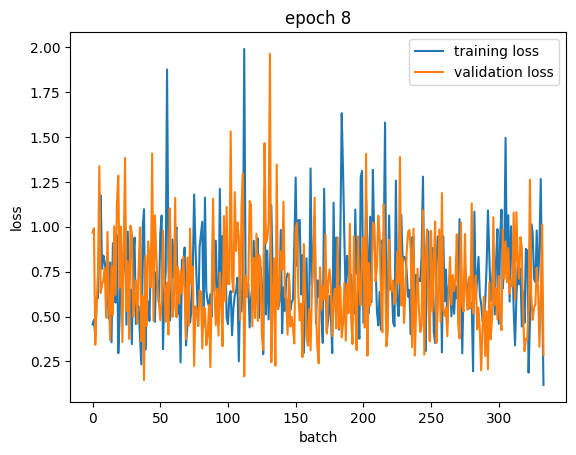

Epoch 9

tensor([2, 6, 0, 7, 7, 6, 0, 9, 6, 6, 9, 7, 9, 1, 8], dtype=torch.uint8)
loss: 0.655525  [    0/60000]
loss: 0.909268  [15000/60000]
loss: 1.545992  [30000/60000]
loss: 0.391714  [45000/60000]
Validation Error:
Accuracy: 74.2%, Avg loss: 0.599096 



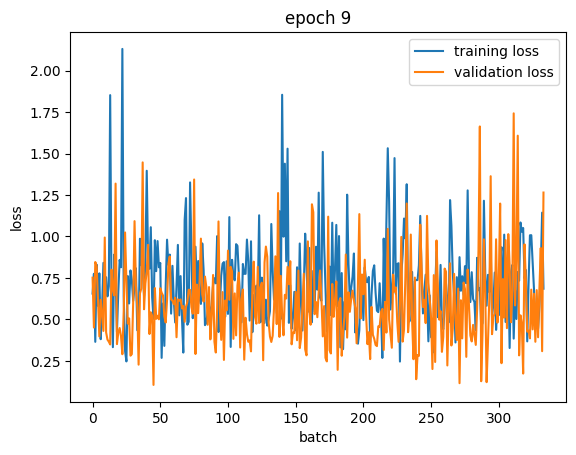

Training: done


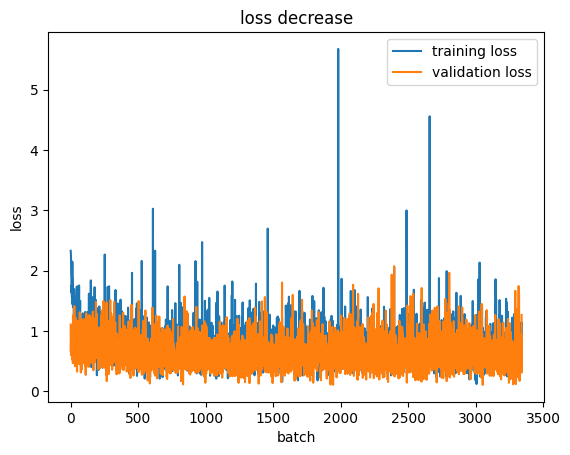


Test Results:
Accuracy: 75.3%, Avg loss: 0.578793 



In [ ]:
epochs = 10

model     = IpLUNetwork(p = 0.25, num_layers=5)
optimizer = torch.optim.Adam(params=model.parameters())
criterion = CrossEntropy()

all_losses_train = []
all_losses_val = []

for t in range(epochs):

    print(f"Epoch {t}\n")

    epoch_train_losses = train_loop(train_dataloader, model, criterion, optimizer)
    all_losses_train = all_losses_train + epoch_train_losses

    print('Validation Error:')


    epoch_val_losses = test_loop(valid_dataloader, model, criterion)
    all_losses_val = all_losses_val + epoch_val_losses

    plt.plot(range(len(epoch_train_losses)), epoch_train_losses, label = 'training loss')
    plt.plot(range(len(epoch_val_losses)), epoch_val_losses, label = 'validation loss')
    plt.xlabel('batch')
    plt.ylabel('loss')
    plt.title(f'epoch {t}')
    plt.legend()
    plt.show()


print("Training: done")


plt.plot(range(len(all_losses_train)), all_losses_train, label = 'training loss')
plt.plot(range(len(all_losses_val)), all_losses_val, label = 'validation loss')
plt.xlabel('batch')
plt.ylabel('loss')
plt.title(f'loss decrease')
plt.legend()
plt.show()

print('\nTest Results:')
a = test_loop(test_dataloader, model, criterion)




In [ ]:
# единичный запуск сработал хуже. test_acc_ReLU = 79.1%  test_acc_IpLU = 75.3%

# попробуем разные параметры alpha

alpha = 1 done
alpha = 1.5 done
alpha = 2 done
alpha = 2.5 done
alpha = 3 done
alpha = 10 done


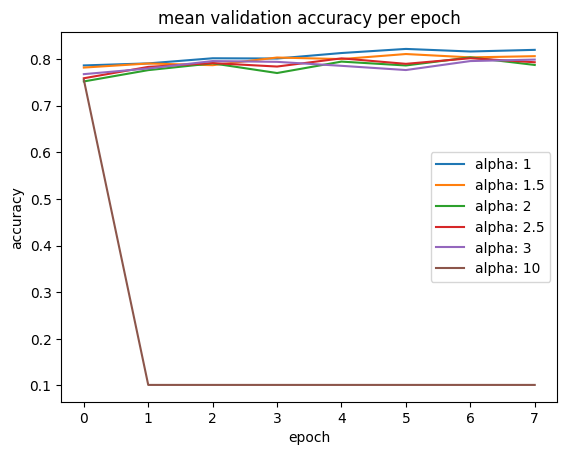

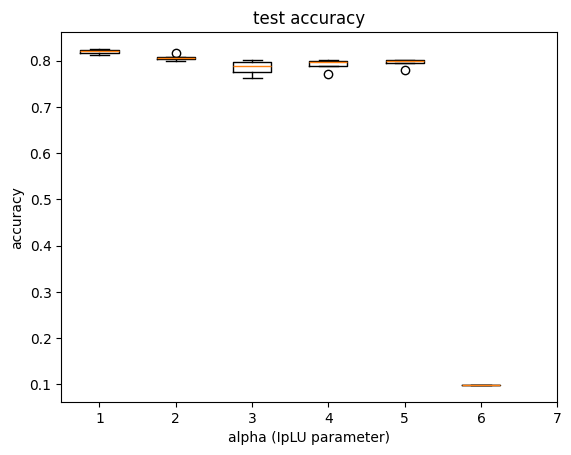

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def train_loop(dataloader, model, loss_fn, optimizer, losses):
    size = len(dataloader.dataset)
    model.train()
    train_losses = []
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        losses.append(loss.item())

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


def test_loop(dataloader, model, loss_fn):

    model.eval()
    test_losses = []

    size = len(dataloader.dataset)

    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
          pred = model(X)
          test_loss = loss_fn(pred, y).item()
          model_labels = model.predict(X)
          correct += (model_labels == y).type(torch.float).sum().item()

          test_losses.append(test_loss)

    correct /= size
    return correct




def run_model_cycle(epochs):

    train_losses = []
    val_acc = []


    for t in range(epochs):
        acc_epochs = []

        train_loop(train_dataloader, model, criterion, optimizer, train_losses)

        val_acc.append(test_loop(valid_dataloader, model, criterion))

    test_acc = test_loop(test_dataloader, model, criterion)

    return val_acc, test_acc


alphas = [1, 1.5, 2, 2.5, 3, 10]  # number of layers
num_layers = 5
num_repeats = 4  # get stat significant results
epochs = 8  # number of epochs

test_accs = []


for a in alphas:

    alpha_val_acc = []
    alpha_test_acc = []


    for rep in range(num_repeats):

        model     = IpLUNetwork(p = 0.25, num_layers=num_layers, iplu_a = a)
        optimizer = torch.optim.Adam(params=model.parameters())
        criterion = CrossEntropy()

        val_acc, test_acc = run_model_cycle(epochs)

        alpha_val_acc.append(val_acc)
        alpha_test_acc.append(test_acc)


    val_acc_per_epoch = list(zip(*alpha_val_acc))
    val_acc_per_epoch = np.array(val_acc_per_epoch).mean(axis = 1)
    test_accs.append(alpha_test_acc)

    plt.plot(range(epochs), val_acc_per_epoch, label = f'alpha: {a}')
    print(f'alpha = {a} done')

plt.title('mean validation accuracy per epoch')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()


plt.boxplot(test_accs)
plt.xticks(range(1, len(num_layers_arr)+1), num_layers_arr)
plt.title('test accuracy')
plt.xlabel('alpha (IpLU parameter)')
plt.ylabel('accuracy')
plt.show()


In [ ]:
np.array(test_accs).mean(axis = 1)

array([0.81965, 0.8072 , 0.78495, 0.7917 , 0.79585, 0.0988 ])

In [ ]:
# alpha = 10 было добавлено для примера и интереса) но картинку это тоже к сожалению подгадило

# лучшее качество получаем при меньше alpha, в частности при alpha = 1, когда IpLU (по форме) очень похожа на GELU/SiLU